In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

### Exercise 12.1

In [3]:
df_E1201 = pd.DataFrame([[(-1)**(i//(2**j)+1) for j in range(4)] for i in range(16)],
                        columns=[_ for _ in '1234'],
)

In [4]:
df_E1201['5'] = df_E1201.prod(axis=1)

In [5]:
df_E1201

,1,2,3,4,5
0,-1,-1,-1,-1,1
1,1,-1,-1,-1,-1
2,-1,1,-1,-1,-1
3,1,1,-1,-1,1
4,-1,-1,1,-1,-1
5,1,-1,1,-1,1
6,-1,1,1,-1,1
7,1,1,1,-1,-1
8,-1,-1,-1,1,-1
9,1,-1,-1,1,1


In [6]:
from itertools import combinations
factors_E1201 = [_ for _ in '12345']
factor_cms_E1201 = []
factor_cms_E1201.extend(combinations(factors_E1201,2))
factor_cms_E1201

[('1', '2'),
 ('1', '3'),
 ('1', '4'),
 ('1', '5'),
 ('2', '3'),
 ('2', '4'),
 ('2', '5'),
 ('3', '4'),
 ('3', '5'),
 ('4', '5')]

In [7]:
for factor_cm in factor_cms_E1201:
    df_E1201[''.join(factor_cm)] = df_E1201[list(factor_cm)].prod(axis=1)

df_E1201

,1,2,3,4,5,12,13,14,15,23,24,25,34,35,45
0,-1,-1,-1,-1,1,1,1,1,-1,1,1,-1,1,-1,-1
1,1,-1,-1,-1,-1,-1,-1,-1,-1,1,1,1,1,1,1
2,-1,1,-1,-1,-1,-1,1,1,1,-1,-1,-1,1,1,1
3,1,1,-1,-1,1,1,-1,-1,1,-1,-1,1,1,-1,-1
4,-1,-1,1,-1,-1,1,-1,1,1,-1,1,1,-1,-1,1
5,1,-1,1,-1,1,-1,1,-1,1,-1,1,-1,-1,1,-1
6,-1,1,1,-1,1,-1,-1,1,-1,1,-1,1,-1,1,-1
7,1,1,1,-1,-1,1,1,-1,-1,1,-1,-1,-1,-1,1
8,-1,-1,-1,1,-1,1,1,-1,1,1,-1,1,-1,1,-1
9,1,-1,-1,1,1,-1,-1,1,1,1,-1,-1,-1,-1,1


In [8]:
df_E1201['response'] = [56,53,63,65,53,55,67,61,69,45,78,93,49,60,95,82]

In [9]:
df_E1201_effects = df_E1201[df_E1201.columns[:-1]].multiply(df_E1201['response'], axis=0).mean(axis=0) * 2

In [10]:
for i in '12345':
    print(df_E1201.groupby(i)['response'].mean())

1
-1    66.25
 1    64.25
Name: response, dtype: float64
2
-1    55.0
 1    75.5
Name: response, dtype: float64
3
-1    65.25
 1    65.25
Name: response, dtype: float64
4
-1    59.125
 1    71.375
Name: response, dtype: float64
5
-1    68.375
 1    62.125
Name: response, dtype: float64


In [11]:
for i in factor_cms_E1201:
    print(df_E1201.groupby(list(i))['response'].mean().diff(2).diff(1)/2)


1   2 
-1  -1    NaN
     1    NaN
 1  -1    NaN
     1    1.5
Name: response, dtype: float64
1   3 
-1  -1    NaN
     1    NaN
 1  -1    NaN
     1    0.5
Name: response, dtype: float64
1   4 
-1  -1     NaN
     1     NaN
 1  -1     NaN
     1   -0.75
Name: response, dtype: float64
1   5 
-1  -1     NaN
     1     NaN
 1  -1     NaN
     1    1.25
Name: response, dtype: float64
2   3 
-1  -1    NaN
     1    NaN
 1  -1    NaN
     1    1.5
Name: response, dtype: float64
2   4 
-1  -1      NaN
     1      NaN
 1  -1      NaN
     1    10.75
Name: response, dtype: float64
2   5 
-1  -1     NaN
     1     NaN
 1  -1     NaN
     1    1.25
Name: response, dtype: float64
3   4 
-1  -1     NaN
     1     NaN
 1  -1     NaN
     1    0.25
Name: response, dtype: float64
3   5 
-1  -1     NaN
     1     NaN
 1  -1     NaN
     1    2.25
Name: response, dtype: float64
4   5 
-1  -1    NaN
     1    NaN
 1  -1    NaN
     1   -9.5
Name: response, dtype: float64


([<matplotlib.axis.YTick at 0x24a9a71c050>,
 [Text(0, -1.2815515655446004, '0.1'),
  Text(0, -0.8416212335729142, '0.2'),
  Text(0, -0.5244005127080407, '0.3'),
  Text(0, -0.2533471031357997, '0.4'),
  Text(0, 0.0, '0.5'),
  Text(0, 0.2533471031357997, '0.6'),
  Text(0, 0.524400512708041, '0.7'),
  Text(0, 0.8416212335729143, '0.8'),
  Text(0, 1.2815515655446004, '0.9')])

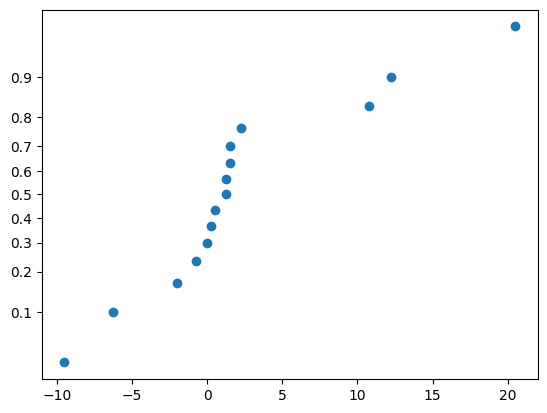

In [12]:
plt.scatter(df_E1201_effects.sort_values(ascending=True), stats.norm.ppf(np.linspace(1 / df_E1201_effects.shape[0]/2, 1-1 / df_E1201_effects.shape[0]/2, df_E1201_effects.shape[0])))
plt.yticks(stats.norm.ppf(np.linspace(0.1,0.9,9)), np.linspace(0.1, 0.9, 9).round(2))

### Table 12.5

In [13]:
df_T1205 = pd.DataFrame({
    'run': np.arange(8)+1,
    '1': [(-1)**(i + 1) for i in range(8)],
    '2': [(-1)**(i//2 + 1) for i in range(8)],
    '3': [(-1)**(i//4 + 1) for i in range(8)],
})
df_T1205['4'] = df_T1205[['1', '2']].prod(axis=1)
df_T1205['5'] = df_T1205[['1', '3']].prod(axis=1)
df_T1205['6'] = df_T1205[['2', '3']].prod(axis=1)
df_T1205['7'] = df_T1205[['1', '2', '3']].prod(axis=1)
df_T1205

,run,1,2,3,4,5,6,7
0,1,-1,-1,-1,1,1,1,-1
1,2,1,-1,-1,-1,-1,1,1
2,3,-1,1,-1,-1,1,-1,1
3,4,1,1,-1,1,-1,-1,-1
4,5,-1,-1,1,1,-1,-1,1
5,6,1,-1,1,-1,1,-1,-1
6,7,-1,1,1,-1,-1,1,-1
7,8,1,1,1,1,1,1,1


In [14]:
df_T1207 = df_T1205.copy()
df_T1207['run'] = df_T1207['run'] + 8
df_T1207['4'] = -df_T1207['4']
df_T1207

,run,1,2,3,4,5,6,7
0,9,-1,-1,-1,-1,1,1,-1
1,10,1,-1,-1,1,-1,1,1
2,11,-1,1,-1,1,1,-1,1
3,12,1,1,-1,-1,-1,-1,-1
4,13,-1,-1,1,-1,-1,-1,1
5,14,1,-1,1,1,1,-1,-1
6,15,-1,1,1,1,-1,1,-1
7,16,1,1,1,-1,1,1,1


In [15]:
def frac_f_2level(k,p):
    '''
    k is the number of variables
    p is the number of omitted variables
    k - p is the number of variables used to construct the design
    '''
    main_f = [str(i) for i in range(1,k-p+1)]
    
    df = pd.DataFrame([[(-1)**(i//(2**j)+1) for j in range(k-p)] for i in range(2**(k-p))],
                      columns=main_f,
                      index=[str(i) for i in range(1, 2**(k-p)+1)])

    comb_f = []
    from itertools import combinations
    for r in range(2, k-p+1):
        comb_f.extend(combinations(main_f, r))
    # print(comb_f)
    for f in comb_f:
        df[''.join(f)] = df[list(f)].prod(axis=1)

    return df

In [16]:
frac_f_2level(15, 11)

,1,2,3,4,12,13,14,23,24,34,123,124,134,234,1234
1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1,-1,-1,1
2,1,-1,-1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1
3,-1,1,-1,-1,-1,1,1,-1,-1,1,1,1,-1,1,-1
4,1,1,-1,-1,1,-1,-1,-1,-1,1,-1,-1,1,1,1
5,-1,-1,1,-1,1,-1,1,-1,1,-1,1,-1,1,1,-1
6,1,-1,1,-1,-1,1,-1,-1,1,-1,-1,1,-1,1,1
7,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,1,1,-1,1
8,1,1,1,-1,1,1,-1,1,-1,-1,1,-1,-1,-1,-1
9,-1,-1,-1,1,1,1,-1,1,-1,-1,-1,1,1,1,-1
10,1,-1,-1,1,-1,-1,1,1,-1,-1,1,-1,-1,1,1


In [17]:
frac_f_2level(63,57)

,1,2,3,4,5,6,12,13,14,15,...,2356,2456,3456,12345,12346,12356,12456,13456,23456,123456
1,-1,-1,-1,-1,-1,-1,1,1,1,1,...,1,1,1,-1,-1,-1,-1,-1,-1,1
2,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,1,1,1,1,1,1,1,1,-1,-1
3,-1,1,-1,-1,-1,-1,-1,1,1,1,...,-1,-1,1,1,1,1,1,-1,1,-1
4,1,1,-1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,1,-1,-1,-1,-1,1,1,1
5,-1,-1,1,-1,-1,-1,1,-1,1,1,...,-1,1,-1,1,1,1,-1,1,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,1,1,-1,1,1,1,1,-1,1,1,...,-1,1,-1,-1,-1,-1,1,-1,-1,-1
61,-1,-1,1,1,1,1,1,-1,-1,-1,...,-1,-1,1,1,1,1,1,-1,-1,1
62,1,-1,1,1,1,1,-1,1,1,1,...,-1,-1,1,-1,-1,-1,-1,1,-1,-1
63,-1,1,1,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,-1,-1,-1,-1,1,-1


In [18]:
frac_f_2level(8,4)

,1,2,3,4,12,13,14,23,24,34,123,124,134,234,1234
1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1,-1,-1,1
2,1,-1,-1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1
3,-1,1,-1,-1,-1,1,1,-1,-1,1,1,1,-1,1,-1
4,1,1,-1,-1,1,-1,-1,-1,-1,1,-1,-1,1,1,1
5,-1,-1,1,-1,1,-1,1,-1,1,-1,1,-1,1,1,-1
6,1,-1,1,-1,-1,1,-1,-1,1,-1,-1,1,-1,1,1
7,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,1,1,-1,1
8,1,1,1,-1,1,1,-1,1,-1,-1,1,-1,-1,-1,-1
9,-1,-1,-1,1,1,1,-1,1,-1,-1,-1,1,1,1,-1
10,1,-1,-1,1,-1,-1,1,1,-1,-1,1,-1,-1,1,1


### Table 12.11

In [19]:
df_T1211 = frac_f_2level(7,4)
df_T1211.columns=[_ for _ in '1234567']
df_T1211['8'] = [1] * 8
df_T1211 = pd.concat((df_T1211, -df_T1211))
df_T1211.index = np.arange(16)+1
df_T1211

,1,2,3,4,5,6,7,8
1,-1,-1,-1,1,1,1,-1,1
2,1,-1,-1,-1,-1,1,1,1
3,-1,1,-1,-1,1,-1,1,1
4,1,1,-1,1,-1,-1,-1,1
5,-1,-1,1,1,-1,-1,1,1
6,1,-1,1,-1,1,-1,-1,1
7,-1,1,1,-1,-1,1,-1,1
8,1,1,1,1,1,1,1,1
9,1,1,1,-1,-1,-1,1,-1
10,-1,1,1,1,1,-1,-1,-1


In [20]:
df_T1213 = df_T1211.copy()
df_T1213['B1'] = df_T1213[['1','2']].prod(axis=1)
df_T1213['B2'] = df_T1213[['1','3']].prod(axis=1)
df_T1213['B3'] = df_T1213[['1','6']].prod(axis=1)
df_T1213

,1,2,3,4,5,6,7,8,B1,B2,B3
1,-1,-1,-1,1,1,1,-1,1,1,1,-1
2,1,-1,-1,-1,-1,1,1,1,-1,-1,1
3,-1,1,-1,-1,1,-1,1,1,-1,1,1
4,1,1,-1,1,-1,-1,-1,1,1,-1,-1
5,-1,-1,1,1,-1,-1,1,1,1,-1,1
6,1,-1,1,-1,1,-1,-1,1,-1,1,-1
7,-1,1,1,-1,-1,1,-1,1,-1,-1,-1
8,1,1,1,1,1,1,1,1,1,1,1
9,1,1,1,-1,-1,-1,1,-1,1,1,-1
10,-1,1,1,1,1,-1,-1,-1,-1,-1,1


In [21]:
df_T1213.sort_values(by=['B1', 'B2', 'B3']) + df_T1213.sort_values(by=['B1', 'B2', 'B3']).shift(1)

,1,2,3,4,5,6,7,8,B1,B2,B3
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,-2.0
2,2.0,-2.0,-2.0,0.0,0.0,0.0,2.0,0.0,-2.0,-2.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,2.0
6,0.0,0.0,2.0,0.0,2.0,-2.0,-2.0,0.0,-2.0,0.0,0.0
14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,2.0,-2.0
3,-2.0,2.0,-2.0,0.0,0.0,0.0,2.0,0.0,-2.0,2.0,0.0
11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,2.0,2.0
4,2.0,0.0,0.0,2.0,-2.0,0.0,-2.0,0.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,-2.0,-2.0


### Problem 12.13

In [22]:
df_T1213 = df_T1211.copy()
df_T1213['y'] = [14.,16.8,15.,15.4,27.6,24.,27.4,22.6,22.3,17.1,21.5,17.5,15.9,21.9,16.7,20.3]
df_T1213

,1,2,3,4,5,6,7,8,y
1,-1,-1,-1,1,1,1,-1,1,14.0
2,1,-1,-1,-1,-1,1,1,1,16.8
3,-1,1,-1,-1,1,-1,1,1,15.0
4,1,1,-1,1,-1,-1,-1,1,15.4
5,-1,-1,1,1,-1,-1,1,1,27.6
6,1,-1,1,-1,1,-1,-1,1,24.0
7,-1,1,1,-1,-1,1,-1,1,27.4
8,1,1,1,1,1,1,1,1,22.6
9,1,1,1,-1,-1,-1,1,-1,22.3
10,-1,1,1,1,1,-1,-1,-1,17.1


In [23]:
df_T1213.sort_values(by=['8', '3', '2', '1'], inplace=True)

In [24]:
df_T1213.index[::2], df_T1213.index[1::2]

(Index([16, 14, 12, 10, 1, 3, 5, 7], dtype='int64'),
 Index([15, 13, 11, 9, 2, 4, 6, 8], dtype='int64'))

In [25]:
df_T1213['y'][df_T1213.index[::2]].reset_index(drop=True) + df_T1213['y'][df_T1213.index[1::2]].reset_index(drop=True)

0    37.0
1    37.8
2    39.0
3    39.4
4    30.8
5    30.4
6    51.6
7    50.0
Name: y, dtype: float64

In [26]:
df_T1213.loc[df_T1213.index[::2], 'y'].reset_index(drop=True) + df_T1213.loc[df_T1213.index[1::2], 'y'].reset_index(drop=True)

0    37.0
1    37.8
2    39.0
3    39.4
4    30.8
5    30.4
6    51.6
7    50.0
Name: y, dtype: float64

In [27]:
df_T1213.loc[df_T1213.index[::2], 'y'].reset_index(drop=True) - df_T1213.loc[df_T1213.index[1::2], 'y'].reset_index(drop=True)

0    3.6
1    6.0
2   -4.0
3   -5.2
4   -2.8
5   -0.4
6    3.6
7    4.8
Name: y, dtype: float64

In [28]:
def yates_algor(pd_serie, n):
    '''
    pd_serie: results in the correct order according to Yates algorithm
    n: number of iterations
    '''
    for i in range(n):
        # print(pd_serie)
        index_1 = pd_serie.index[::2]
        index_2 = pd_serie.index[1::2]
        serie_1 = pd_serie[index_1].reset_index(drop=True) + pd_serie[index_2].reset_index(drop=True)
        serie_2 = -pd_serie[index_1].reset_index(drop=True) + pd_serie[index_2].reset_index(drop=True)
        pd_serie = pd.concat((serie_1, serie_2)).reset_index(drop=True)

    pd_serie = pd_serie / pd_serie.shape[0] * 2
    pd_serie.iloc[0] = pd_serie.iloc[0] / 2
    return pd_serie

In [29]:
yates_algor(df_T1213['y'], 4)

0     19.75
1     -0.70
2     -0.10
3     -0.60
4      5.50
5      0.90
6     -0.20
7      0.60
8      1.20
9     -0.60
10    -0.40
11    -0.30
12     4.60
13    -3.80
14    -0.10
15    -0.30
Name: y, dtype: float64

In [30]:
df_T1213['y'].mean()

np.float64(19.75)

In [31]:
df_T1213.groupby('1')['y'].mean().diff(1)

1
-1    NaN
 1   -0.7
Name: y, dtype: float64

### Question 12.13

In [ ]:
# df_Q1213 = frac_f_2level(5,2)
# df_Q1213['4'] = [1]*8
# df_Q1213 = pd.concat((df_Q1213, -df_Q1213))
# df_Q1213.index = np.arange(16)+1
# df_Q1213['14'] = df_Q1213[['1','4']].prod(axis=1)
# df_Q1213

,1,2,3,12,13,23,123,4,14
1,-1,-1,-1,1,1,1,-1,1,-1
2,1,-1,-1,-1,-1,1,1,1,1
3,-1,1,-1,-1,1,-1,1,1,-1
4,1,1,-1,1,-1,-1,-1,1,1
5,-1,-1,1,1,-1,-1,1,1,-1
6,1,-1,1,-1,1,-1,-1,1,1
7,-1,1,1,-1,-1,1,-1,1,-1
8,1,1,1,1,1,1,1,1,1
9,1,1,1,-1,-1,-1,1,-1,-1
10,-1,1,1,1,1,-1,-1,-1,1


In [ ]:
# df_Q1213.sort_values(by=['12', '13', '14'])

,1,2,3,12,13,23,123,4,14
7,-1,1,1,-1,-1,1,-1,1,-1
9,1,1,1,-1,-1,-1,1,-1,-1
2,1,-1,-1,-1,-1,1,1,1,1
16,-1,-1,-1,-1,-1,-1,-1,-1,1
3,-1,1,-1,-1,1,-1,1,1,-1
13,1,1,-1,-1,1,1,-1,-1,-1
6,1,-1,1,-1,1,-1,-1,1,1
12,-1,-1,1,-1,1,1,1,-1,1
5,-1,-1,1,1,-1,-1,1,1,-1
11,1,-1,1,1,-1,1,-1,-1,-1


In [42]:
df_Q1213 = frac_f_2level(5,1)
df_Q1213.sort_values(by=['12','13','14'])

,1,2,3,4,12,13,14,23,24,34,123,124,134,234,1234
2,1,-1,-1,-1,-1,-1,-1,1,1,1,1,1,1,-1,-1
15,-1,1,1,1,-1,-1,-1,1,1,1,-1,-1,-1,1,-1
7,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,1,1,-1,1
10,1,-1,-1,1,-1,-1,1,1,-1,-1,1,-1,-1,1,1
6,1,-1,1,-1,-1,1,-1,-1,1,-1,-1,1,-1,1,1
11,-1,1,-1,1,-1,1,-1,-1,1,-1,1,-1,1,-1,1
3,-1,1,-1,-1,-1,1,1,-1,-1,1,1,1,-1,1,-1
14,1,-1,1,1,-1,1,1,-1,-1,1,-1,-1,1,-1,-1
4,1,1,-1,-1,1,-1,-1,-1,-1,1,-1,-1,1,1,1
13,-1,-1,1,1,1,-1,-1,-1,-1,1,1,1,-1,-1,1
